# 03 - Multivariate analysis + PCA + Clustering (ALI 2022)

This notebook:
- explores correlations between indicators
- applies transformations for skewed variables
- runs PCA to understand structure and dimensionality
- performs clustering (k-means)
- visualizes clusters and interprets cluster characteristics

Inputs:
- `data/processed/ali_2022_imputed.csv`

Outputs:
- figures saved to `outputs/figures/`
- a table of cluster summaries for the report

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
PATH = "../data/processed/ali_2022_imputed.csv"
df = pd.read_csv(PATH)

df.head(), df.shape

(       country iso3  year  gdp_per_capita_ppp_const  unemployment_rate  \
 0        Aruba  ABW  2022              38979.835825           5.512170   
 1  Afghanistan  AFG  2022               1981.710168          14.100000   
 2       Angola  AGO  2022               8950.142593          14.124000   
 3      Albania  ALB  2022              19388.873133          10.785000   
 4      Andorra  AND  2022              63913.383508          11.149912   
 
    labor_force_participation  life_expectancy  ppp_conversion_factor  
 0                  60.761253           76.226               1.327790  
 1                  37.640000           65.617              14.897971  
 2                  75.247000           64.246             191.953512  
 3                  62.161000           78.769              39.608065  
 4                  54.375607           84.016               0.588248  ,
 (209, 8))

In [3]:
features = [
    "gdp_per_capita_ppp_const",
    "unemployment_rate",
    "labor_force_participation",
    "life_expectancy",
    "ppp_conversion_factor"
]

df[features].describe().T

,count,mean,std,min,25%,50%,75%,max
gdp_per_capita_ppp_const,209.0,26656.150004,26177.782345,1031.254122,6418.174984,17119.574495,39864.010088,133571.962410
unemployment_rate,209.0,7.235356,5.567440,0.130000,3.591000,5.570000,9.250000,36.472000
labor_force_participation,209.0,60.342851,10.623449,23.509000,55.218000,60.835000,65.964000,87.575000
life_expectancy,209.0,72.830015,7.923014,18.818000,67.675000,74.125000,77.911000,85.708000
ppp_conversion_factor,209.0,630.143802,5037.720877,0.085160,0.918072,4.624378,84.098765,71200.145632


'../outputs/figures/hist_raw_indicators.png'

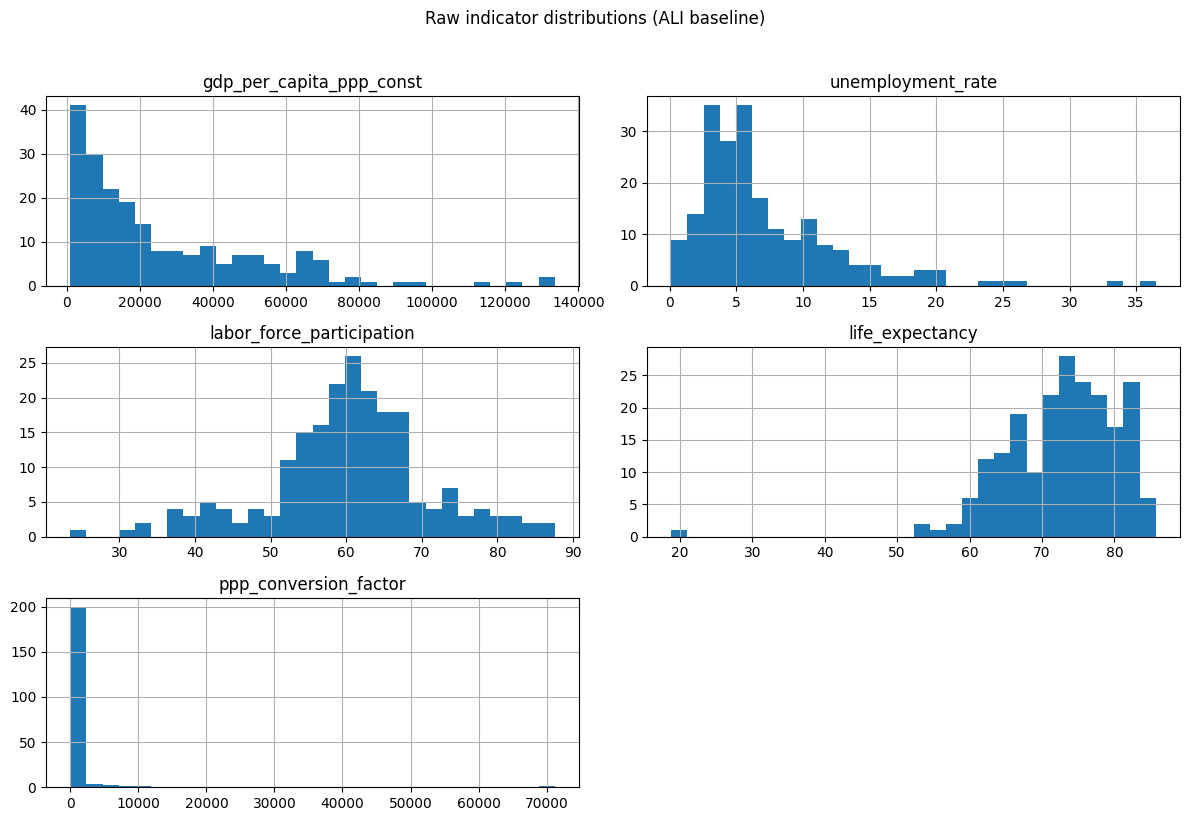

In [4]:
df[features].hist(figsize=(12, 8), bins=30)
plt.suptitle("Raw indicator distributions (ALI baseline)", y=1.02)
plt.tight_layout()

fig_path = "../outputs/figures/hist_raw_indicators.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
fig_path

In [ ]:
df_t = df.copy()

# log1p is safe if values can be small (log(1+x))
df_t["log_gdp_pc"] = np.log1p(df_t["gdp_per_capita_ppp_const"])
df_t["log_ppp_conv"] = np.log1p(df_t["ppp_conversion_factor"])

features_for_ml = [
    "log_gdp_pc",
    "unemployment_rate",
    "labor_force_participation",
    "life_expectancy",
    "log_ppp_conv"
]

df_t[features_for_ml].describe().T

,count,mean,std,min,25%,50%,75%,max
log_gdp_pc,209.0,9.650446,1.140894,6.939500,8.767045,9.748036,10.593254,11.802403
unemployment_rate,209.0,7.235356,5.567440,0.130000,3.591000,5.570000,9.250000,36.472000
labor_force_participation,209.0,60.342851,10.623449,23.509000,55.218000,60.835000,65.964000,87.575000
life_expectancy,209.0,72.830015,7.923014,18.818000,67.675000,74.125000,77.911000,85.708000
log_ppp_conv,209.0,2.612557,2.383369,0.081727,0.651321,1.727110,4.443813,11.173264


'../outputs/figures/corr_matrix_transformed.png'

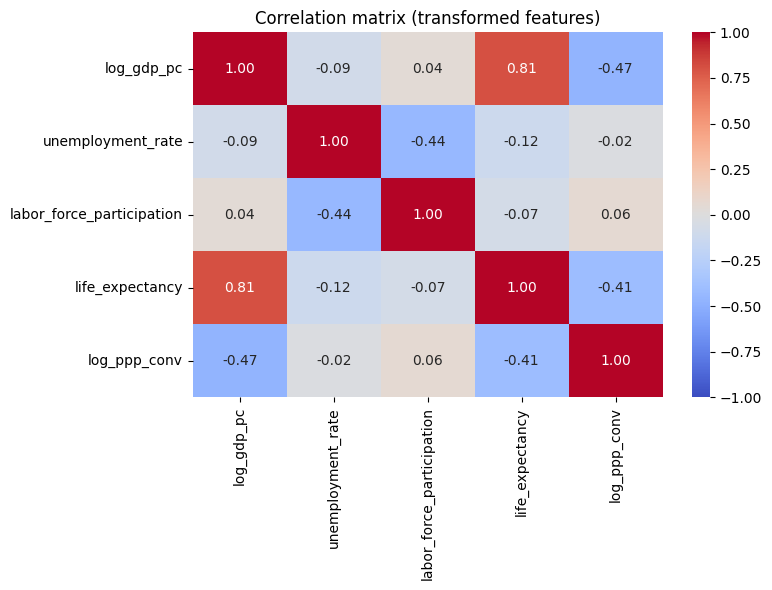

In [6]:
corr = df_t[features_for_ml].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation matrix (transformed features)")
plt.tight_layout()

fig_path = "../outputs/figures/corr_matrix_transformed.png"
plt.savefig(fig_path, dpi=200)
fig_path

In [7]:
X = df_t[features_for_ml].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape

(209, 5)

Explained variance ratio (PC1, PC2): [0.43142028 0.2896103 ] Total: 0.7210305786502296


'../outputs/figures/pca_scatter.png'

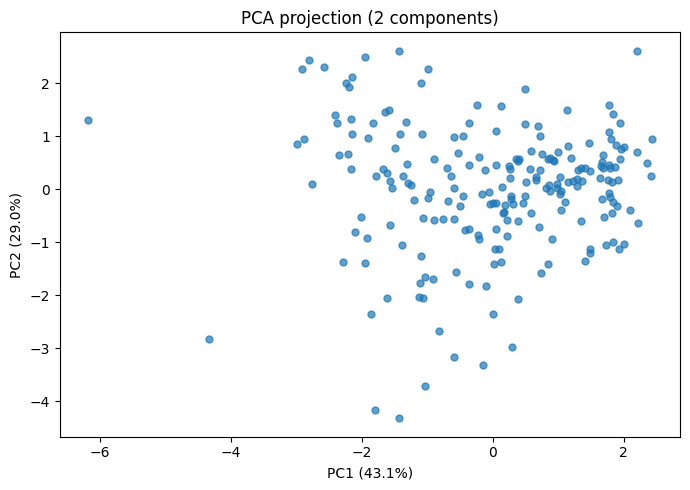

In [8]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print("Explained variance ratio (PC1, PC2):", explained, "Total:", explained.sum())

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=25, alpha=0.7)
plt.xlabel(f"PC1 ({explained[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({explained[1]*100:.1f}%)")
plt.title("PCA projection (2 components)")
plt.tight_layout()

fig_path = "../outputs/figures/pca_scatter.png"
plt.savefig(fig_path, dpi=200)
fig_path

In [9]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=features_for_ml,
    columns=["PC1", "PC2"]
)
loadings

,PC1,PC2
log_gdp_pc,0.627023,0.012779
unemployment_rate,-0.103640,-0.694551
labor_force_participation,0.002306,0.705282
life_expectancy,0.613859,-0.027042
log_ppp_conv,-0.468266,0.138859


'../outputs/figures/silhouette_by_k.png'

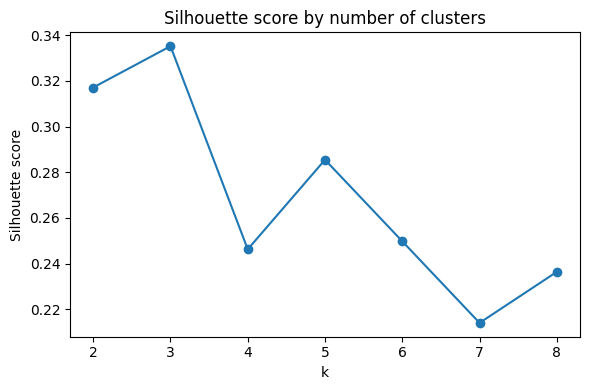

In [10]:
scores = []
ks = range(2, 9)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(list(ks), scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette score by number of clusters")
plt.tight_layout()

fig_path = "../outputs/figures/silhouette_by_k.png"
plt.savefig(fig_path, dpi=200)
fig_path

In [11]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_t["cluster"] = kmeans.fit_predict(X_scaled)

df_t["cluster"].value_counts().sort_index()

cluster
0    25
1    90
2    39
3    55
Name: count, dtype: int64

'../outputs/figures/pca_clusters.png'

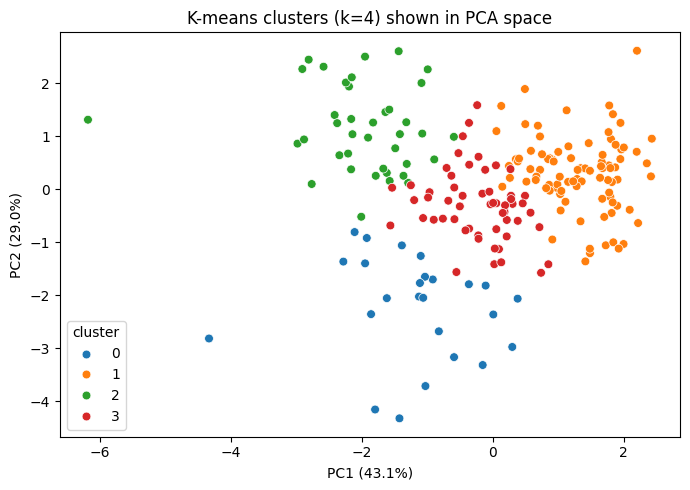

In [12]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df_t["cluster"], palette="tab10", s=40)
plt.xlabel(f"PC1 ({explained[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({explained[1]*100:.1f}%)")
plt.title(f"K-means clusters (k={k}) shown in PCA space")
plt.legend(title="cluster")
plt.tight_layout()

fig_path = "../outputs/figures/pca_clusters.png"
plt.savefig(fig_path, dpi=200)
fig_path

In [13]:
cluster_summary = df_t.groupby("cluster")[features].mean().round(2)
cluster_summary

,gdp_per_capita_ppp_const,unemployment_rate,labor_force_participation,life_expectancy,ppp_conversion_factor
cluster,,,,,
0,8760.56,17.52,45.03,68.99,3695.48
1,49068.91,5.29,62.51,78.86,23.24
2,5424.37,4.25,69.08,63.74,891.31
3,13170.34,7.87,57.57,71.14,44.74


In [14]:
# Mean z-scores per cluster
df_z = pd.DataFrame(X_scaled, columns=features_for_ml)
df_z["cluster"] = df_t["cluster"].values

cluster_z = df_z.groupby("cluster").mean().round(2)
cluster_z

,log_gdp_pc,unemployment_rate,labor_force_participation,life_expectancy,log_ppp_conv
cluster,,,,,
0,-0.69,1.85,-1.45,-0.49,0.54
1,0.90,-0.35,0.20,0.76,-0.53
2,-1.19,-0.54,0.82,-1.15,1.26
3,-0.32,0.11,-0.26,-0.21,-0.27


In [15]:
OUT_PATH = "../data/processed/ali_2022_with_clusters.csv"
df_t[["country","iso3","year"] + features + ["cluster"]].to_csv(OUT_PATH, index=False)
OUT_PATH

'../data/processed/ali_2022_with_clusters.csv'

In [17]:
import statsmodels.api as sm

y = df_t["life_expectancy"]
Xr = df_t[["log_gdp_pc", "unemployment_rate", "labor_force_participation", "log_ppp_conv"]]
Xr = sm.add_constant(Xr)

model = sm.OLS(y, Xr).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        life_expectancy   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.672
Method:                 Least Squares   F-statistic:                     107.4
Date:                Wed, 20 May 2026   Prob (F-statistic):           4.47e-49
Time:                        17:37:13   Log-Likelihood:                -610.23
No. Observations:                 209   AIC:                             1230.
Df Residuals:                     204   BIC:                             1247.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        28.4222      3.911      7.267      0.000      20.711      36.134
log_gdp_pc                    5.4949      0.315     17.463      0.000       4.874       6.115
unemployment_rate            -0.1730      0.063     -2.738      0.007      -0.298      -0.048
labor_force_participation    -0.1179      0.033     -3.565      0.000      -0.183      -0.053
log_ppp_conv                 -0.0983      0.150     -0.654      0.514      -0.395       0.198
==============================================================================
Omnibus:                      180.655   Durbin-Watson:                   2.047
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5012.155
Skew:                          -3.046   Prob(JB):                         0.00
Kurtosis:                      26.205   Cond. No.                         779.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""